3_1. (12.11.25)


2. На датасете "gen_regression" постройте модель пятого, десятого и сотого порядков. Сравните эффективность и время обучения каждой модели.

In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML3.1%20polynomial%20features/data/gen_regression.csv")
X = data.x
y = data.y
X = pd.DataFrame(X)

print("МОДЕЛЬ 5-ГО ПОРЯДКА")
start_time = time.time()
transformation_5 = PolynomialFeatures(degree=5)
X_5 = transformation_5.fit_transform(X)
model_5 = LinearRegression().fit(X_5, y)
time_5 = time.time() - start_time

score_5 = model_5.score(X_5, y)

print(f"Время обучения: {time_5:.4f} сек")
print(f"R² score: {score_5:.4f}")

print("\nМОДЕЛЬ 10-ГО ПОРЯДКА")
start_time = time.time()
transformation_10 = PolynomialFeatures(degree=10)
X_10 = transformation_10.fit_transform(X)
model_10 = LinearRegression().fit(X_10, y)
time_10 = time.time() - start_time

score_10 = model_10.score(X_10, y)

print(f"Время обучения: {time_10:.4f} сек")
print(f"R² score: {score_10:.4f}")

print("\nМОДЕЛЬ 100-ГО ПОРЯДКА")
start_time = time.time()
transformation_100 = PolynomialFeatures(degree=100)
X_100 = transformation_100.fit_transform(X)
model_100 = LinearRegression().fit(X_100, y)
time_100 = time.time() - start_time

score_100 = model_100.score(X_100, y)

print(f"Время обучения: {time_100:.4f} сек")
print(f"R² score: {score_100:.4f}")

print("\nСРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("Степень | Время обучения(с)| R² score")
print(f"5       | {time_5:.4f}           | {score_5:.4f}")
print(f"10      | {time_10:.4f}           | {score_10:.4f}")
print(f"100     | {time_100:.4f}           | {score_100:.4f}")

print("\nАНАЛИЗ ПЕРЕОБУЧЕНИЯ")
print(f"Улучшение от 5 к 10 степени: {score_10 - score_5:.4f}")
print(f"Улучшение от 10 к 100 степени: {score_100 - score_10:.4f}")

МОДЕЛЬ 5-ГО ПОРЯДКА
Время обучения: 0.0130 сек
R² score: 0.9217

МОДЕЛЬ 10-ГО ПОРЯДКА
Время обучения: 0.0184 сек
R² score: 0.9222

МОДЕЛЬ 100-ГО ПОРЯДКА
Время обучения: 0.0705 сек
R² score: 0.7925

СРАВНИТЕЛЬНАЯ ТАБЛИЦА
Степень | Время обучения(с)| R² score
5       | 0.0130           | 0.9217
10      | 0.0184           | 0.9222
100     | 0.0705           | 0.7925

АНАЛИЗ ПЕРЕОБУЧЕНИЯ
Улучшение от 5 к 10 степени: 0.0005
Улучшение от 10 к 100 степени: -0.1298


3_2. (19.11.25)

6. Сгенерируйте датасет для классификации из 1000 точек и 5 атрибутов. Попробуйте применить метод опорных векторов на нем. Найдите методом подбора наилучшее ядро и значение С.

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics

X_large, y_large = make_classification(n_samples=1000, n_features=5, n_redundant=0,
                                     n_informative=5, n_clusters_per_class=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_large, y_large, test_size=0.3, random_state=42)

best_accuracy = 0
best_params = {}

for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10, 100]:
        if kernel == 'poly':
            svm = SVC(kernel=kernel, C=C, degree=3)
        else:
            svm = SVC(kernel=kernel, C=C)

        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_test)
        accuracy = metrics.accuracy_score(y_test, y_pred)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_params = {'kernel': kernel, 'C': C}

        print(f"Ядро {kernel}, C={C}: Точность={accuracy:.3f}")
print(f"\nЛучшие параметры: {best_params}, Точность={best_accuracy:.3f}")

Ядро linear, C=0.1: Точность=0.977
Ядро linear, C=1: Точность=0.977
Ядро linear, C=10: Точность=0.980
Ядро linear, C=100: Точность=0.980
Ядро rbf, C=0.1: Точность=0.983
Ядро rbf, C=1: Точность=0.993
Ядро rbf, C=10: Точность=0.990
Ядро rbf, C=100: Точность=0.983
Ядро poly, C=0.1: Точность=0.973
Ядро poly, C=1: Точность=0.983
Ядро poly, C=10: Точность=0.993
Ядро poly, C=100: Точность=0.973

Лучшие параметры: {'kernel': 'rbf', 'C': 1}, Точность=0.993


3_3. (26.11.25)

1. Создайте однослойный перцептрон с 1, 2, 10 и 100 нейронами. Сравние их точность и сделайте вывод о достаточном количестве нейронов.

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200,
                  centers=blob_centers,
                  cluster_std=0.5,
                  random_state=0)
X[:, 0] *= 1000
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
######
######
neurons_list = [1, 2, 10, 100]
accuracies = []

print("Эксперимент с однослойным перцептроном")

for neurons in neurons_list:
    clf = MLPClassifier(hidden_layer_sizes=(neurons,),
                       max_iter=1000,
                       random_state=42)

    clf.fit(X_scaled, y)

    y_pred = clf.predict(X_scaled)

    accuracy = accuracy_score(y, y_pred)
    accuracies.append(accuracy)

    print(f"Нейронов: {neurons:3d}, Точность: {accuracy:.4f}")

Эксперимент с однослойным перцептроном


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Нейронов:   1, Точность: 0.3950


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Нейронов:   2, Точность: 0.9750
Нейронов:  10, Точность: 0.9850
Нейронов: 100, Точность: 0.9950


При 1 нейроне точность низкая: 39.5% - недостаточно для разделения 4 классов

При 2 нейронах точность резко возрастает до 97.5% - этого уже достаточно

При 10 нейронах точность незначительно улучшается до 98.5% - улучшение минимальное

При 100 нейронах точность максимальна: 99.5%, но выигрыш незначительный

Оптимальное количество: 2 нейрона - дают 97.5% точности при минимальной сложности

3_4. (10.12.25)

5. Загрузите весь датасет load_iris. Обучите модель классификационного дерева принятия решений sklearn.tree.DecisionTreeClassifier глубины 4, используя энтропию. Визуализируйте соответствующий граф дерева решений. Оцените качество работы модели.

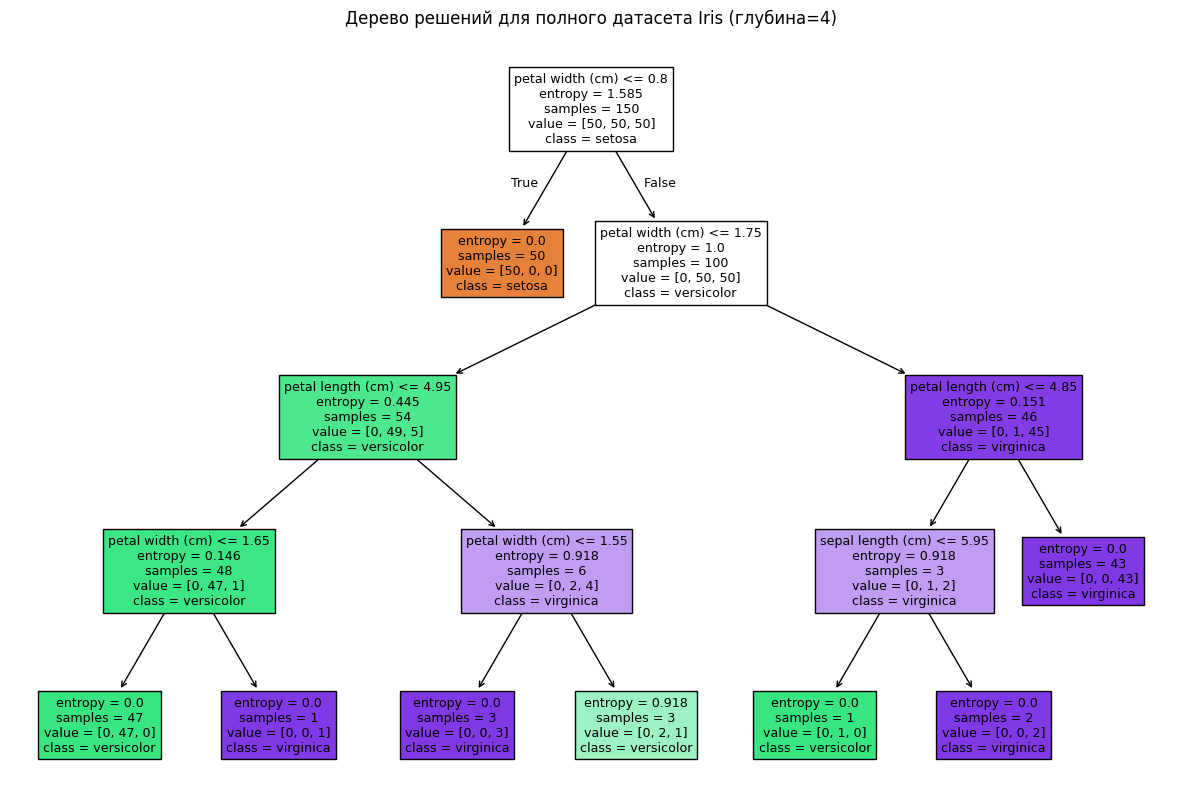


Качество модели на полном датасете Iris:
Accuracy = 0.9933

Матрица ошибок:
[[50  0  0]
 [ 0 50  0]
 [ 0  1 49]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
X_iris_full = iris.data
y_iris_full = iris.target

clf_iris_full = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
clf_iris_full.fit(X_iris_full, y_iris_full)

plt.figure(figsize=(15, 10))
plot_tree(clf_iris_full,
          filled=True,
          feature_names=iris.feature_names,
          class_names=iris.target_names)
plt.title('Дерево решений для полного датасета Iris (глубина=4)')
plt.show()

y_pred_full = clf_iris_full.predict(X_iris_full)
accuracy_full = accuracy_score(y_iris_full, y_pred_full)

print(f"\nКачество модели на полном датасете Iris:")
print(f"Accuracy = {accuracy_full:.4f}")
print("\nМатрица ошибок:")
print(confusion_matrix(y_iris_full, y_pred_full))

Accuracy 99.33% показывает отличное качество модели.

Матрица ошибок: 2 класса распознаются идеально (100%),
только 1 образец ошибочно был выделен в другой класс.


3_5. (17.10.25)

1. Постройте последний график методических указаний в исходном пространстве признаков.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


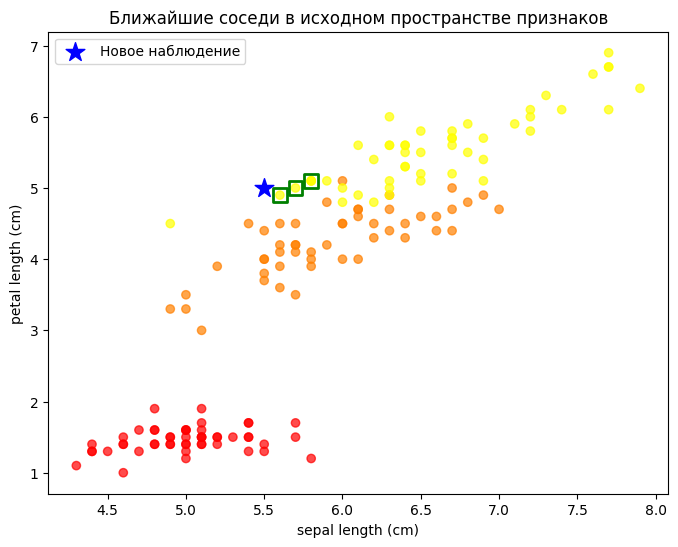

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)

X = data.iloc[:, [0, 2]]
y = iris.target

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

observation_new = [[5.5, 5]]
observation_new_scaled = scaler.transform(observation_new)
distances, indices = knn.kneighbors(observation_new_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn', alpha=0.7)
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=200, color='blue', label='Новое наблюдение')

for i in indices[0]:
    plt.scatter(X.iloc[i, 0], X.iloc[i, 1], marker='s', s=100, edgecolors='green', facecolors='none', linewidth=2)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title('Ближайшие соседи в исходном пространстве признаков')
plt.legend()
plt.show()